# Bab 4: Regression and Prediction

Notebook ini membahas **regresi dan prediksi** berdasarkan *Practical Statistics for Data Scientists*. Contoh utama menggunakan data penjualan rumah di King County.

### Materi
1. Simple Linear Regression
2. Multiple Linear Regression
3. Prediction Using Regression
4. Factor Variables in Regression
5. Interpreting the Regression Equation
6. Regression Diagnostics
7. Polynomial and Spline Regression
8. Generalized Additive Models (GAM)


<a href="https://colab.research.google.com/github/mohamadnurtaufiq/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library dan Dataset
Dataset `house_sales.csv` berisi informasi penjualan rumah. Variabel yang digunakan antara lain harga jual yang disesuaikan, luas bangunan, luas tanah, kamar mandi, kamar tidur, kualitas bangunan, dan kode pos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option("display.precision", 4)
BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"
house = pd.read_csv(BASE + "house_sales.csv", sep="\t")
house = house.loc[house["PropertyType"] == "Single Family"].copy()
print("Ukuran data:", house.shape)
house.head()


Ukuran data: (20720, 22)


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.9292,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.9779,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.9614,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.8079,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
7,2013-08-28,327500,3800004,Single Family,2013-08-01,374300,0.8601,380785.0,1,34465,...,1.50,3,8,1961,0,0,165000,227000,98178,False


## 2. Variabel yang Digunakan
- `AdjSalePrice`: harga jual yang sudah disesuaikan
- `SqFtTotLiving`: luas bangunan
- `SqFtLot`: luas tanah
- `Bathrooms`: jumlah kamar mandi
- `Bedrooms`: jumlah kamar tidur
- `BldgGrade`: tingkat kualitas bangunan

Variabel target yang digunakan adalah `AdjSalePrice`.


In [ ]:
house[["AdjSalePrice", "SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"]].head()


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7
7,380785.0,1750,34465,1.50,3,8


## 3. Simple Linear Regression
Regresi linear sederhana digunakan untuk melihat hubungan antara satu variabel prediktor dengan target.

Model: **Y = β₀ + β₁X + ε**

Pada contoh ini, `SqFtTotLiving` digunakan untuk memprediksi `AdjSalePrice`.


In [ ]:
model_simple = smf.ols("AdjSalePrice ~ SqFtTotLiving", data=house).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                 1.950e+04
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:44:58   Log-Likelihood:            -2.8973e+05
No. Observations:               20720   AIC:                         5.795e+05
Df Residuals:                   20718   BIC:                         5.795e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -6.106e+04   4972.846    -12.278

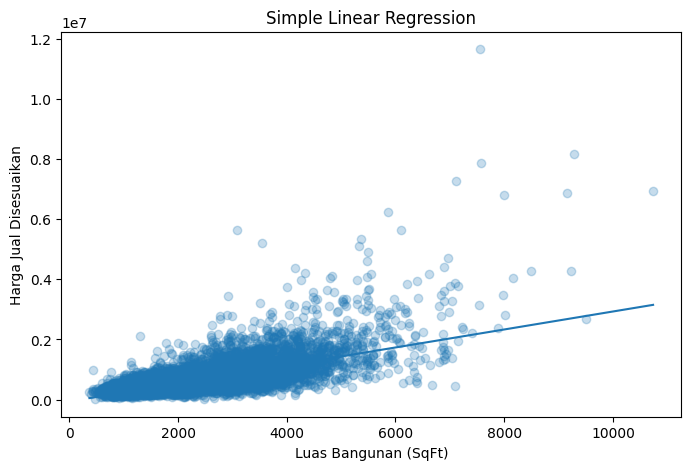

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(house["SqFtTotLiving"], house["AdjSalePrice"], alpha=0.25)
x = np.linspace(house["SqFtTotLiving"].min(), house["SqFtTotLiving"].max(), 100)
y = model_simple.params["Intercept"] + model_simple.params["SqFtTotLiving"] * x
plt.plot(x, y)
plt.xlabel("Luas Bangunan (SqFt)")
plt.ylabel("Harga Jual Disesuaikan")
plt.title("Simple Linear Regression")
plt.show()


### Interpretasi
Koefisien `SqFtTotLiving` menunjukkan perubahan rata-rata harga yang berhubungan dengan penambahan luas bangunan. Jika koefisien positif, hubungan modelnya positif.


## 4. Residual dan R-squared
Residual adalah selisih antara nilai aktual dan nilai yang diprediksi model. R-squared (R²) menunjukkan proporsi variasi target yang dapat dijelaskan oleh model.


In [ ]:
print("R-squared:", model_simple.rsquared)
print("Adjusted R-squared:", model_simple.rsquared_adj)
print("\nContoh residual:")
print(model_simple.resid.head())


R-squared: 0.48481231621577914
Adjusted R-squared: 0.48478744954506836

Contoh residual:
2     12485.4281
3    207307.0697
4   -453080.6130
5   -155836.2530
7    -81080.6657
dtype: float64


## 5. Multiple Linear Regression
Regresi linear berganda menggunakan beberapa prediktor secara bersamaan. Dengan demikian, model dapat mempertimbangkan beberapa karakteristik rumah sekaligus.


In [ ]:
model_multiple = smf.ols(
    "AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + BldgGrade",
    data=house
).fit()
print(model_multiple.summary())


                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     4834.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:45:07   Log-Likelihood:            -2.8859e+05
No. Observations:               20720   AIC:                         5.772e+05
Df Residuals:                   20714   BIC:                         5.772e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5.246e+05   1.69e+04    -31.060

In [ ]:
coef_table = pd.DataFrame({
    "Koefisien": model_multiple.params,
    "P-value": model_multiple.pvalues
})
coef_table


,Koefisien,P-value
Intercept,-524602.9323,4.6035e-207
SqFtTotLiving,228.1369,0.0000e+00
SqFtLot,-0.0769,2.2626e-01
Bathrooms,-20372.1814,1.0898e-06
Bedrooms,-53036.4823,3.5858e-83
BldgGrade,109396.5303,0.0000e+00


### Interpretasi Koefisien
Koefisien suatu prediktor menunjukkan perubahan rata-rata pada harga ketika prediktor tersebut berubah satu unit, dengan prediktor lain dalam model dianggap tetap.


## 6. Prediction Using Regression
Model regresi dapat digunakan untuk memperkirakan harga rumah baru berdasarkan karakteristik yang diberikan.


In [ ]:
new_house = pd.DataFrame({
    "SqFtTotLiving": [2000, 3000],
    "SqFtLot": [8000, 12000],
    "Bathrooms": [2.0, 3.0],
    "Bedrooms": [3, 4],
    "BldgGrade": [7, 9]
})
new_house["PredictedPrice"] = model_multiple.predict(new_house)
new_house


,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,PredictedPrice
0,2000,8000,2.0,3,7,496977.2233
1,3000,12000,3.0,4,9,870190.7468


## 7. Factor Variables in Regression
Variabel kategori dapat dimasukkan ke model menggunakan `C()`. Contohnya adalah `ZipCode`, yang diperlakukan sebagai kategori, bukan angka dengan jarak numerik.


In [ ]:
top_zip = house["ZipCode"].value_counts().head(5).index
house_zip = house[house["ZipCode"].isin(top_zip)].copy()
model_factor = smf.ols("AdjSalePrice ~ SqFtTotLiving + C(ZipCode)", data=house_zip).fit()
print(model_factor.summary())


                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     1183.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:45:44   Log-Likelihood:                -40815.
No. Observations:                3104   AIC:                         8.164e+04
Df Residuals:                    3098   BIC:                         8.168e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.349e+04   8

## 8. Interpreting the Regression Equation
Persamaan regresi dapat ditulis sebagai:

**Harga = Intercept + koefisien₁X₁ + koefisien₂X₂ + ...**

Intercept merupakan nilai dasar model, sedangkan koefisien menunjukkan arah dan besar hubungan masing-masing prediktor. P-value dapat digunakan untuk melihat signifikansi statistik koefisien.


## 9. Regression Diagnostics
Setelah model dibuat, residual perlu diperiksa. Pemeriksaan ini membantu melihat apakah terdapat pola tertentu, outlier, atau masalah pada asumsi model.


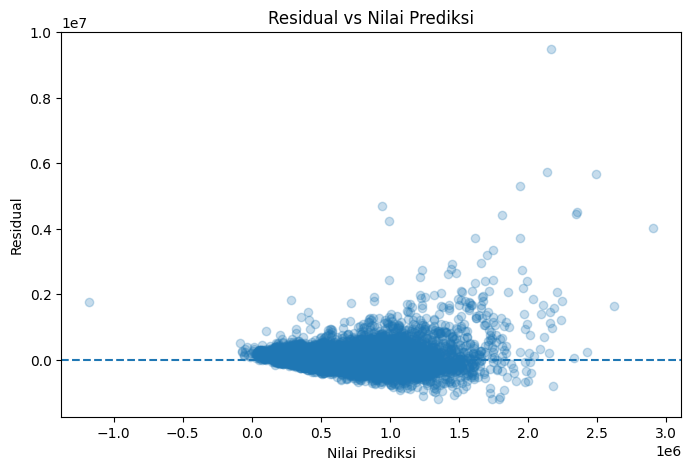

In [ ]:
fitted = model_multiple.fittedvalues
resid = model_multiple.resid
plt.figure(figsize=(8,5))
plt.scatter(fitted, resid, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Nilai Prediksi")
plt.ylabel("Residual")
plt.title("Residual vs Nilai Prediksi")
plt.show()


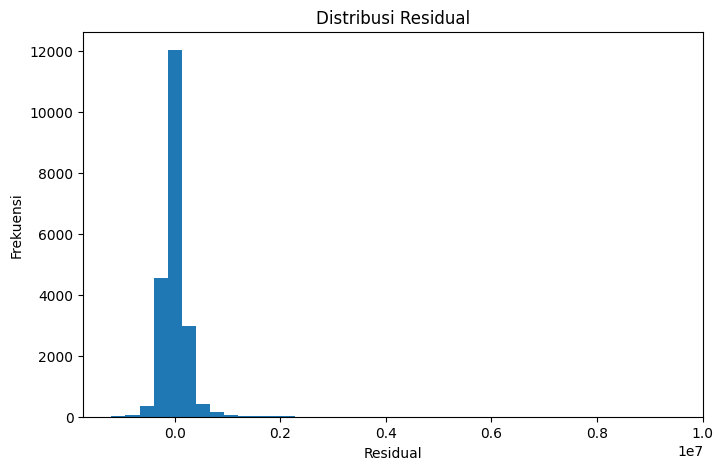

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(resid, bins=40)
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.title("Distribusi Residual")
plt.show()


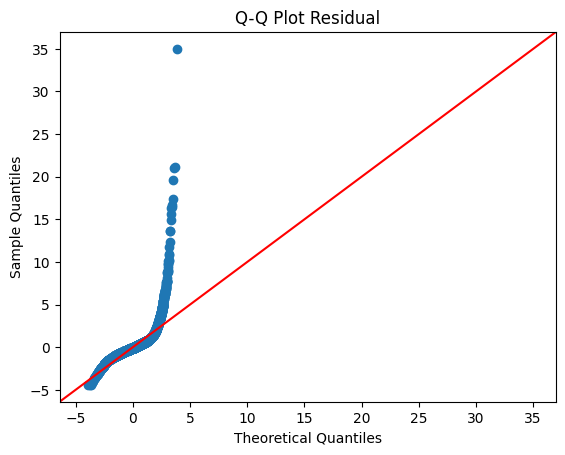

In [ ]:
sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q Plot Residual")
plt.show()


### Interpretasi Diagnostic Plot
Residual yang tersebar tanpa pola yang jelas lebih sesuai dengan model linear. Q-Q plot digunakan untuk melihat apakah residual mendekati distribusi normal.


## 10. Polynomial Regression
Jika hubungan antara prediktor dan target tidak sepenuhnya linear, pangkat variabel dapat ditambahkan. Contoh model:

**Y = β₀ + β₁X + β₂X² + ε**


In [ ]:
house_poly = house[["AdjSalePrice", "SqFtTotLiving"]].dropna().copy()
house_poly["SqFtTotLiving2"] = house_poly["SqFtTotLiving"] ** 2
model_poly = smf.ols("AdjSalePrice ~ SqFtTotLiving + SqFtTotLiving2", data=house_poly).fit()
print(model_poly.summary())


                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                 1.258e+04
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:45:59   Log-Likelihood:            -2.8836e+05
No. Observations:               20720   AIC:                         5.767e+05
Df Residuals:                   20717   BIC:                         5.768e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       3.103e+05   8299.691     37.

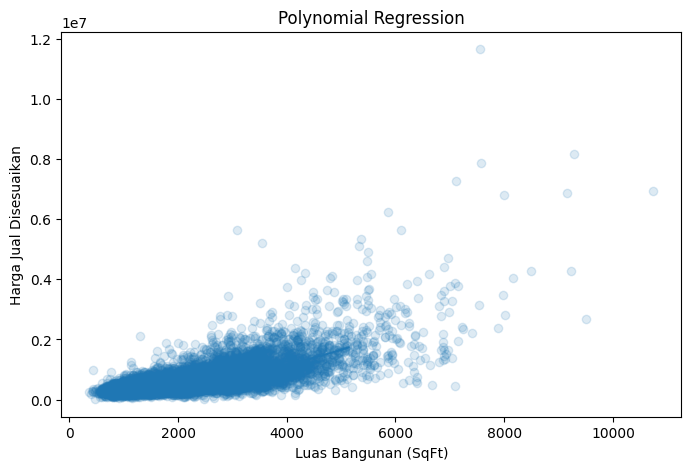

In [ ]:
x = np.linspace(house_poly["SqFtTotLiving"].quantile(.01), house_poly["SqFtTotLiving"].quantile(.99), 200)
plot_data = pd.DataFrame({"SqFtTotLiving": x, "SqFtTotLiving2": x**2})
y = model_poly.predict(plot_data)
plt.figure(figsize=(8,5))
plt.scatter(house_poly["SqFtTotLiving"], house_poly["AdjSalePrice"], alpha=.15)
plt.plot(x, y)
plt.xlabel("Luas Bangunan (SqFt)")
plt.ylabel("Harga Jual Disesuaikan")
plt.title("Polynomial Regression")
plt.show()


## 11. Spline Regression
Spline regression membuat hubungan yang lebih fleksibel dengan membagi rentang prediktor menjadi beberapa bagian. Pendekatan ini berguna ketika hubungan X dan Y berubah pada rentang tertentu.


In [ ]:
from patsy import dmatrix
spline_basis = dmatrix(
    "bs(SqFtTotLiving, df=6, degree=3, include_intercept=False)",
    data=house_poly, return_type="dataframe"
)
spline_model = sm.OLS(house_poly["AdjSalePrice"], sm.add_constant(spline_basis)).fit()
print(spline_model.summary())


## 12. Generalized Additive Models (GAM)
GAM menggunakan fungsi yang fleksibel untuk menggambarkan hubungan non-linear. Secara sederhana:

**Y = β₀ + f₁(X₁) + f₂(X₂) + ... + ε**

Dalam notebook ini, spline basis digunakan sebagai ilustrasi pendekatan hubungan non-linear.


In [ ]:
from patsy import dmatrix

In [ ]:
gam_design = dmatrix(
    "bs(SqFtTotLiving, df=6, degree=3, include_intercept=False)",
    data=house_poly, return_type="dataframe"
)
gam_model = sm.OLS(house_poly["AdjSalePrice"], sm.add_constant(gam_design)).fit()
print("R-squared model spline:", gam_model.rsquared)


R-squared model spline: 0.548740820173619


# Kesimpulan Bab 4
Bab 4 menjelaskan penggunaan regresi untuk memahami hubungan antarvariabel dan membuat prediksi. Regresi linear sederhana menggunakan satu prediktor, sedangkan regresi berganda menggunakan beberapa prediktor.

Selain melihat koefisien dan R², model perlu diperiksa menggunakan residual dan diagnostic plot. Jika hubungan tidak linear, polynomial regression dan spline dapat digunakan untuk membuat model yang lebih fleksibel.

Pada data penjualan rumah, luas bangunan, luas tanah, jumlah kamar mandi, jumlah kamar tidur, dan kualitas bangunan dapat digunakan sebagai variabel untuk membantu memodelkan harga rumah.
